In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# How many rows and columns?
df = pd.read_csv('/kaggle/input/datasets/ishanabharathi/voters/33-Constituency-Wise-Detailed-Result.csv', 
                 header=2,
                 encoding='latin1')



print("Shape:", df.shape)

# What are the column names?
print("\nColumns:")
print(df.columns.tolist())


In [3]:
# Drop useless columns
df = df.drop(columns=['Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19'])

# Rename columns to simpler names
df.columns = ['State', 'Constituency', 'Candidate', 'Gender', 'Age', 
              'Category', 'Party', 'Symbol', 'Total_Votes_Polled', 
              'Valid_Votes', 'General_Votes', 'Postal_Votes', 
              'Votes_Secured', 'Pct_Over_Electors', 
              'Pct_Over_Votes_Polled', 'Pct_Over_Valid_Votes', 
              'Total_Electors']
df.head()

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Quick look
df.head()

Missing values:
State                      5
Constituency               8
Candidate                  8
Gender                   550
Age                      550
Category                 550
Party                      8
Symbol                     8
Total_Votes_Polled         8
Valid_Votes                8
General_Votes              8
Postal_Votes               8
Votes_Secured              8
Pct_Over_Electors          8
Pct_Over_Votes_Polled      8
Pct_Over_Valid_Votes       8
Total_Electors             8
dtype: int64


,State,Constituency,Candidate,Gender,Age,Category,Party,Symbol,Total_Votes_Polled,Valid_Votes,General_Votes,Postal_Votes,Votes_Secured,Pct_Over_Electors,Pct_Over_Votes_Polled,Pct_Over_Valid_Votes,Total_Electors
0,Andhra Pradesh,Araku,GUMMA THANUJA RANI,FEMALE,31.0,ST,YSRCP,Ceiling fan,1165787.0,1113975.0,471470.0,5535.0,477005.0,30.63,40.92,42.82,1557153.0
1,Andhra Pradesh,Araku,KOTHAPALLI GEETHA,FEMALE,53.0,ST,BJP,Lotus,1165787.0,1113975.0,417113.0,9312.0,426425.0,27.38,36.58,38.28,1557153.0
2,Andhra Pradesh,Araku,APPALANARASA PACHIPENTA,MALE,41.0,ST,CPI(M),"Hammer, Sickle and Star",1165787.0,1113975.0,119016.0,4113.0,123129.0,7.91,10.56,11.05,1557153.0
3,Andhra Pradesh,Araku,NOTA,NaN,NaN,NaN,NOTA,NOTA,1165787.0,1113975.0,50205.0,265.0,50470.0,3.24,4.33,4.53,1557153.0
4,Andhra Pradesh,Araku,AVASHYA LAHARI . VARAM,FEMALE,30.0,ST,BSP,Elephant,1165787.0,1113975.0,24858.0,892.0,25750.0,1.65,2.21,2.31,1557153.0


In [4]:
# Fill missing State and Constituency 
# (they're missing because Excel merged cells)
df['State'] = df['State'].ffill()
df['Constituency'] = df['Constituency'].ffill()

# Fill missing Gender, Age, Category with 'Unknown'
df['Gender'] = df['Gender'].fillna('Unknown')
df['Age'] = df['Age'].fillna(0)
df['Category'] = df['Category'].fillna('Unknown')

# Drop remaining missing rows (only 8 rows - very small)
df = df.dropna()

# Confirm - should show all zeros now
print("Missing values after fix:")
print(df.isnull().sum())

print("\nShape now:", df.shape)

Missing values after fix:
State                    0
Constituency             0
Candidate                0
Gender                   0
Age                      0
Category                 0
Party                    0
Symbol                   0
Total_Votes_Polled       0
Valid_Votes              0
General_Votes            0
Postal_Votes             0
Votes_Secured            0
Pct_Over_Electors        0
Pct_Over_Votes_Polled    0
Pct_Over_Valid_Votes     0
Total_Electors           0
dtype: int64

Shape now: (8901, 17)


In [5]:
# Find the winner of each constituency
# (candidate with highest votes in each constituency)

df['Is_Winner'] = df.groupby('Constituency')['Votes_Secured'].transform(
    lambda x: (x == x.max()).astype(int)
)

# Check - should show 0s and 1s
print("Winners found:", df['Is_Winner'].sum())
print("Total constituencies:", df['Constituency'].nunique())

# See what a winner row looks like
df[df['Is_Winner'] == 1].head()

Winners found: 540
Total constituencies: 540


,State,Constituency,Candidate,Gender,Age,Category,Party,Symbol,Total_Votes_Polled,Valid_Votes,General_Votes,Postal_Votes,Votes_Secured,Pct_Over_Electors,Pct_Over_Votes_Polled,Pct_Over_Valid_Votes,Total_Electors,Is_Winner
0,Andhra Pradesh,Araku,GUMMA THANUJA RANI,FEMALE,31.0,ST,YSRCP,Ceiling fan,1165787.0,1113975.0,471470.0,5535.0,477005.0,30.63,40.92,42.82,1557153.0,1
14,Andhra Pradesh,Srikakulam,KINJARAPU RAMMOHAN NAIDU,MALE,36.0,GENERAL,TDP,Bicycle,1241169.0,1211081.0,734501.0,19827.0,754328.0,45.81,60.78,62.29,1646686.0,1
28,Andhra Pradesh,Vizianagaram,APPALANAIDU KALISETTI,MALE,50.0,GENERAL,TDP,Bicycle,1307632.0,1275992.0,729284.0,13829.0,743113.0,46.71,56.83,58.24,1590994.0,1
44,Andhra Pradesh,Visakhapatnam,SRIBHARAT MATHUKUMILI,MALE,35.0,GENERAL,TDP,Bicycle,1391130.0,1381812.0,893884.0,13583.0,907467.0,46.98,65.23,65.67,1931398.0,1
78,Andhra Pradesh,Anakapalle,C.M.RAMESH,MALE,58.0,GENERAL,BJP,Lotus,1328726.0,1299097.0,750027.0,12042.0,762069.0,47.59,57.35,58.66,1601365.0,1


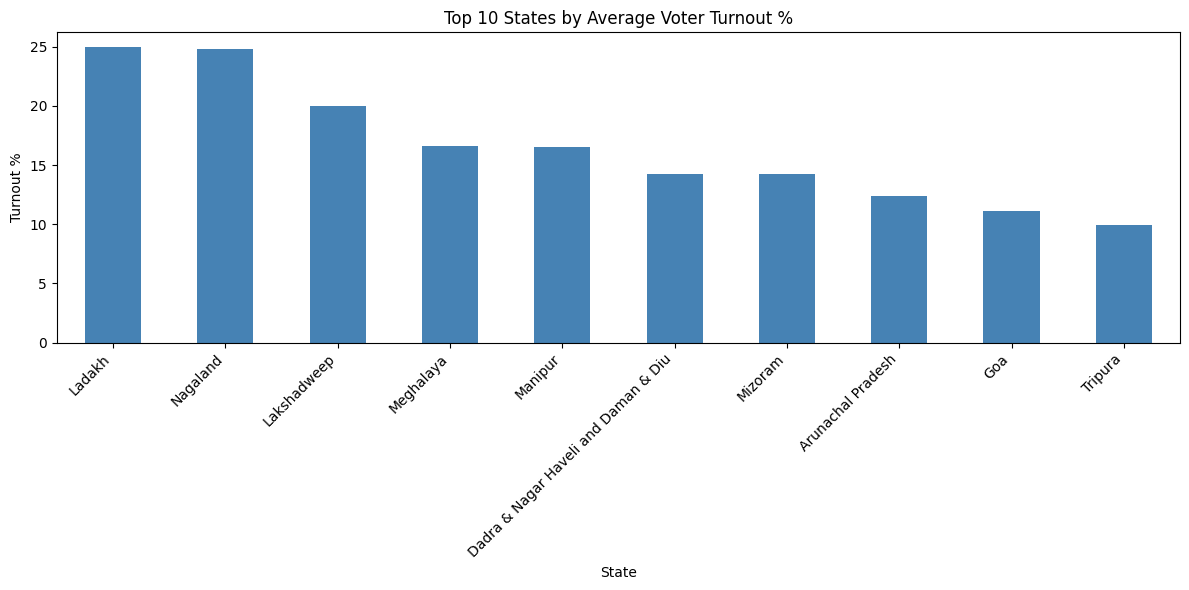

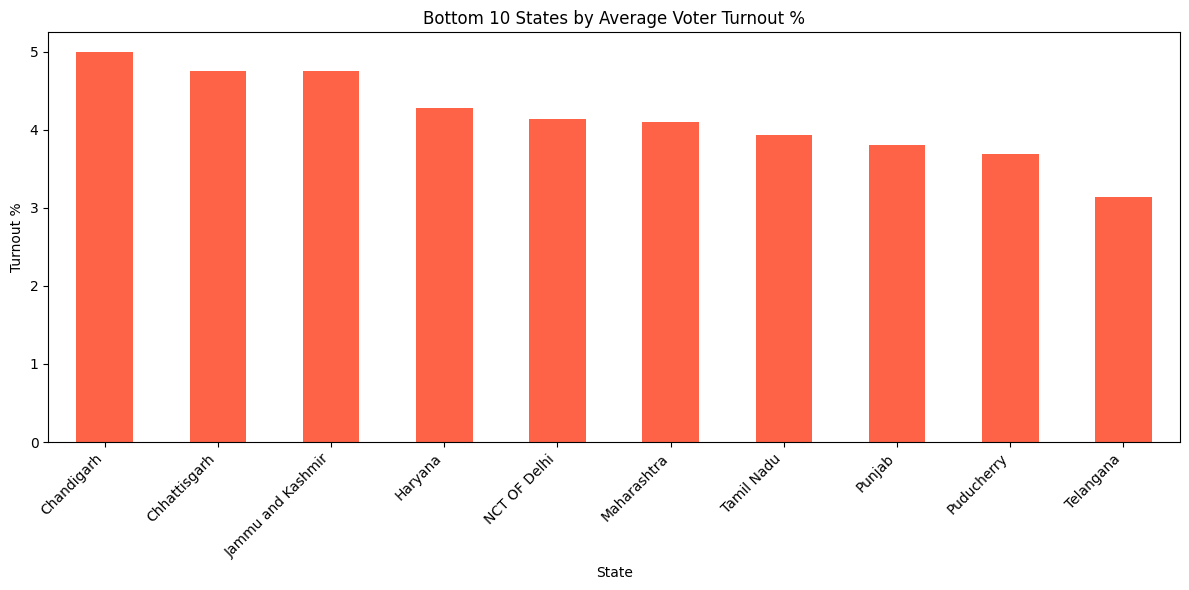

In [6]:
# Top 10 states by voter turnout
state_turnout = df.groupby('State')['Pct_Over_Votes_Polled'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
state_turnout.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 States by Average Voter Turnout %')
plt.xlabel('State')
plt.ylabel('Turnout %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Bottom 10 states
plt.figure(figsize=(12, 6))
state_turnout.tail(10).plot(kind='bar', color='tomato')
plt.title('Bottom 10 States by Average Voter Turnout %')
plt.xlabel('State')
plt.ylabel('Turnout %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# This counts how many candidates contested per constituency
# More candidates = more competition = more interesting fight

# groupby Constituency = group all rows by constituency name
# ['Candidate'].count() = count how many candidates in each group
candidates_per_constituency = df.groupby('Constituency')['Candidate'].count().sort_values(ascending=False)

print("Average candidates per constituency:", 
      round(candidates_per_constituency.mean(), 1))

# Show top 10 most contested constituencies
print("\nMost contested constituencies:")
print(candidates_per_constituency.head(10))

Average candidates per constituency: 16.5

Most contested constituencies:
Constituency
KARUR            55
Aurangabad       48
Secunderabad     46
Medak            45
Chevella         44
Ludhiana         44
Warangal         43
Peddapalle       43
Beed             42
CHENNAI SOUTH    42
Name: Candidate, dtype: int64


In [8]:
df_sorted = df.sort_values(['Constituency', 'Votes_Secured'], ascending=[True, False])

top2 = df_sorted.groupby('Constituency').head(2)
top2.head(6)

,State,Constituency,Candidate,Gender,Age,Category,Party,Symbol,Total_Votes_Polled,Valid_Votes,General_Votes,Postal_Votes,Votes_Secured,Pct_Over_Electors,Pct_Over_Votes_Polled,Pct_Over_Valid_Votes,Total_Electors,Is_Winner
4786,Rajasthan,AJMER,BHAGIRATH CHOUDHARY,MALE,69.0,GENERAL,BJP,Lotus,1202835.0,1189777.0,741151.0,6311.0,747462.0,37.38,62.14,62.82,1999399.0,1
4787,Rajasthan,AJMER,RAMCHANDRA CHOUDHARY,MALE,79.0,GENERAL,INC,Hand,1202835.0,1189777.0,413685.0,3786.0,417471.0,20.88,34.71,35.09,1999399.0,0
4746,Rajasthan,ALWAR,BHUPENDER YADAV,MALE,55.0,GENERAL,BJP,Lotus,1256821.0,1247616.0,624110.0,7882.0,631992.0,30.46,50.28,50.66,2075093.0,1
4747,Rajasthan,ALWAR,LALIT YADAV,MALE,37.0,GENERAL,INC,Hand,1256821.0,1247616.0,575964.0,7746.0,583710.0,28.13,46.44,46.79,2075093.0,0
1497,Haryana,AMBALA,VARUN CHAUDHRY,MALE,44.0,SC,INC,Hand,1348094.0,1340270.0,662592.0,1065.0,663657.0,33.12,49.23,49.52,2003510.0,1
1498,Haryana,AMBALA,BANTO KATARIA,FEMALE,59.0,SC,BJP,Lotus,1348094.0,1340270.0,613786.0,835.0,614621.0,30.68,45.59,45.86,2003510.0,0


In [9]:
# Group constituencies alphabetically, then rank candidates inside them by votes
df_s=df.sort_values(['Constituency', 'Votes_Secured'], ascending=[True, False])
top2=df_s.groupby('Constituency').head(2)

margin=top2.groupby('Constituency')['Votes_Secured'].diff().abs()
margin.head()
#top2.head()

4786         NaN
4787    329991.0
4746         NaN
4747     48282.0
1497         NaN
Name: Votes_Secured, dtype: float64

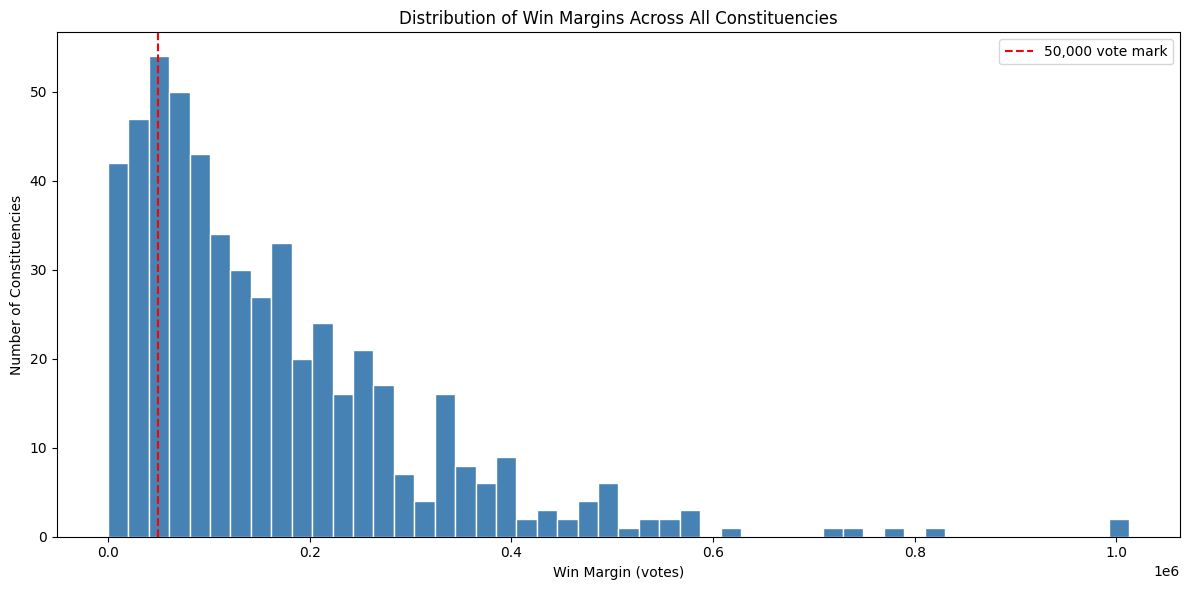

In [10]:
# plt.figure = set chart size
plt.figure(figsize=(12, 6))

# hist = histogram
# bins=50 = divide data into 50 groups
# color and edgecolor = styling
plt.hist(margin, bins=50, color='steelblue', edgecolor='white')

# labels and title
plt.title('Distribution of Win Margins Across All Constituencies')
plt.xlabel('Win Margin (votes)')  # x axis = margin size
plt.ylabel('Number of Constituencies')  # y axis = how many

# this draws a vertical red line at 50000 votes
# anything LEFT of this line = very close fight!
plt.axvline(x=50000, color='red', linestyle='--', label='50,000 vote mark')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Step 1: Count number of candidates per constituency
# This tells us how competitive each constituency was
candidates_count = df.groupby('Constituency')['Candidate'].count().reset_index()
candidates_count.columns = ['Constituency', 'Num_Candidates']

# Step 2: Get constituency level data
# We take only winner rows since they have constituency level info
constituency_df = df[df['Is_Winner'] == 1][['Constituency', 'State', 
                                             'Category', 'Total_Electors',
                                             'Total_Votes_Polled',
                                             'Pct_Over_Votes_Polled']].copy()

# Step 3: Merge candidate count into constituency data
constituency_df = constituency_df.merge(candidates_count, on='Constituency')

# Step 4: Check what we have
print("Shape:", constituency_df.shape)
print("\nFirst few rows:")
constituency_df.head()

print(constituency_df.describe())

Shape: (540, 7)

First few rows:
       Total_Electors  Total_Votes_Polled  Pct_Over_Votes_Polled  \
count    5.400000e+02        5.400000e+02             540.000000   
mean     1.803976e+06        1.193444e+06              50.256426   
std      3.609405e+05        2.450893e+05               7.681758   
min      5.795300e+04        4.924700e+04              23.650000   
25%      1.637910e+06        1.061658e+06              45.975000   
50%      1.823077e+06        1.179524e+06              49.700000   
75%      1.983377e+06        1.349964e+06              54.055000   
max      3.780453e+06        2.458780e+06              78.500000   

       Num_Candidates  
count      540.000000  
mean        16.483333  
std          8.380432  
min          4.000000  
25%         11.000000  
50%         14.000000  
75%         20.000000  
max         55.000000  


In [21]:
# Install required library
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries loaded!")

Libraries loaded!


In [34]:

df_model = pd.get_dummies(constituency_df, 
                           columns=['State', 'Category'])
X = df_model.drop(columns=['Constituency', 'Pct_Over_Votes_Polled', 
                             'Total_Votes_Polled'])
Y = df_model['Pct_Over_Votes_Polled']

# Step 3: Split again
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, 
                                                              test_size=0.15, 
                                                              random_state=42)

# Second split — separate validation from training (15% of total)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, 
                                                    test_size=0.176, 
                                                   random_state=42)
print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Testing size:", X_test.shape)
# # Step 4: Train again
model1 = LinearRegression()
model1.fit(X_train, Y_train)

# Step 5: Test again
Y_pred = model1.predict(X_test)
Y_pV=model1.predict(X_val)
Y_pt=model1.predict(X_train)

r2_2 = r2_score(Y_test, Y_pred)
r2_21 = r2_score(Y_val, Y_pV)
r2_22= r2_score(Y_train, Y_pt)
print(mae2)
print(r2_2,' ',r2_21,' ',r2_22)

Training size: (378, 41)
Validation size: (81, 41)
Testing size: (81, 41)
4.474818638832184
0.4297514598122082   0.41391873789662414   0.5045413167520955


In [14]:
# Load 2019 data
df_2019 = pd.read_csv('/kaggle/input/datasets/ishanabharathi/voter2019/33-Constituency-wise-detailed-result-2019.csv', 
                 header=2,
                 encoding='latin1')

print(df_2019.columns.tolist())

[' State Name ', ' PC NAME ', ' CANDIDATES NAME ', ' SEX ', ' AGE ', ' CATEGORY ', ' PARTY NAME ', ' PARTY SYMBOL ', ' GENERAL ', ' POSTAL ', ' TOTAL ', 'OVER TOTAL ELECTORS IN CONSTITUENCY', 'OVER TOTAL VOTES POLLED IN CONSTITUENCY', 'Total Electors']


In [15]:


# Rename to simpler names
df_2019.columns = ['State', 'Constituency', 'Candidate', 'Gender', 'Age', 
                    'Category', 'Party', 'Symbol', 'General_Votes', 
                    'Postal_Votes', 'Votes_Secured', 'Pct_Over_Electors',
                    'Pct_Over_Votes_Polled', 'Total_Electors']

# Fill missing State and Constituency (merged cells problem)
df_2019['State'] = df_2019['State'].ffill()
df_2019['Constituency'] = df_2019['Constituency'].ffill()

# Find 2019 winners
df_2019['Is_Winner'] = df_2019.groupby('Constituency')['Votes_Secured'].transform(
    lambda x: (x == x.max()).astype(int)
)

# Keep only winners
winners_2019 = df_2019[df_2019['Is_Winner'] == 1][['Constituency', 'Party']]
winners_2019.columns = ['Constituency', 'Party_2019']

print("2019 winners found:", len(winners_2019))
winners_2019.head()

2019 winners found: 540


,Constituency,Party_2019
2,Aruku,YSRCP
11,Srikakulam,TDP
23,Vizianagaram,YSRCP
39,Visakhapatnam,YSRCP
53,Anakapalli,YSRCP


In [42]:
winners_2024 = df[df['Is_Winner'] == 1][['Constituency', 'Party']]
winners_2024.columns = ['Constituency', 'Party_2024']
name_mapping = {
    'AHMADNAGAR': 'AHMEDNAGAR',
    'ANAKAPALLI': 'ANAKAPALLE',
    'ANANTAPUR': 'ANANTHAPUR',
    'ANANTNAG': 'ANANTNAG-RAJOURI',
    'ARAMBAGH': 'ARAMBAG',
    'AUTONOMOUS DISTRICT': 'DIPHU',
    'BAHRAICH': 'BAHARAICH',
    'BARDHAMAN DURGAPUR': 'BARDHAMAN-DURGAPUR',
    'BARRACKPORE': 'BARRACKPUR',
    'BHANDARA - GONDIYA': 'BHANDARA GONDIYA',
    'BIKANER (SC)': 'BIKANER',
    'COOCH BEHAR': 'COOCHBEHAR',
    'DADRA AND NAGAR HAVELI': 'DADAR & NAGAR HAVELI',
    'GADCHIROLI-CHIMUR': 'GADCHIROLI - CHIMUR',
    'GAUHATI': 'GUWAHATI',
    'GAYA (SC)': 'GAYA',
    'GOPALGANJ (SC)': 'GOPALGANJ',
    'HAJIPUR (SC)': 'HAJIPUR',
    'HARDWAR': 'HARIDWAR',
    'HATKANANGLE': 'HATKANANGALE',
    'JAMUI (SC)': 'JAMUI',
    'KALIABOR': 'KAZIRANGA',
    'KURNOOL': 'KURNOOLU',
    'MANGALDOI': 'DARRANG-UDALGURI',
    'MUMBAI   SOUTH': 'MUMBAI SOUTH',
    'NARASARAOPET': 'NARSARAOPET',
    'NORTH EAST DELHI': 'NORTH-EAST DELHI',
    'NORTH WEST DELHI': 'NORTH-WEST DELHI',
    'NOWGONG': 'NAGAON',
    'PALAMAU': 'PALAMU',
    'PATALIPUTRA': 'PATLIPUTRA',
    'RATNAGIRI - SINDHUDURG': 'RATNAGIRI- SINDHUDURG',
    'SAMASTIPUR (SC)': 'SAMASTIPUR',
    'SARGUJA': 'SURGUJA',
    'SASARAM (SC)': 'SASARAM',
    'SECUNDRABAD': 'SECUNDERABAD',
    'SRERAMPUR': 'SREERAMPUR',
    'TEZPUR': 'SONITPUR',
    'THIRUVALLUR': 'TIRUVALLUR',
    'TIRUPATI': 'THIRUPATHI',
    'YAVATMAL-WASHIM': 'YAVATMAL- WASHIM',
}

# Apply mapping
winners_2019['Constituency'] = winners_2019['Constituency'].replace(name_mapping)
# Convert all constituency names to UPPERCASE in both datasets
winners_2019['Constituency'] = winners_2019['Constituency'].str.upper().str.strip()
winners_2024['Constituency'] = winners_2024['Constituency'].str.upper().str.strip()

# Merge again
incumbency_df = winners_2019.merge(winners_2024, on='Constituency')

# Compare again
incumbency_df['Anti_Incumbency'] = (
    incumbency_df['Party_2019'] != incumbency_df['Party_2024']
).astype(int)

total = len(incumbency_df)
anti = incumbency_df['Anti_Incumbency'].sum()
retained = total - anti

print(f"Total constituencies: {total}")
print(f"Anti-incumbency (party changed): {anti} ({round(anti/total*100,1)}%)")
print(f"Retained (same party won): {retained} ({round(retained/total*100,1)}%)")

Total constituencies: 539
Anti-incumbency (party changed): 214 (39.7%)
Retained (same party won): 325 (60.3%)


In [44]:
# Rebuild margins completely from scratch
df_sorted2 = df.copy()
df_sorted2['Constituency'] = df_sorted2['Constituency'].str.upper().str.strip()

# Sort by constituency and votes
df_sorted2 = df_sorted2.sort_values(['Constituency', 'Votes_Secured'], 
                                     ascending=[True, False])

# Get top 2 per constituency
top2 = df_sorted2.groupby('Constituency').head(2)

# Calculate margin
margins_df = top2.groupby('Constituency')['Votes_Secured'].apply(
    lambda x: x.iloc[0] - x.iloc[1] if len(x) == 2 else None
).reset_index()

margins_df.columns = ['Constituency', 'Win_Margin']

print("Sample:")
print(margins_df.head(10))

Sample:
     Constituency  Win_Margin
0        ADILABAD     90652.0
1            AGRA    271294.0
2  AHMEDABAD EAST    461755.0
3  AHMEDABAD WEST    286437.0
4      AHMEDNAGAR     28929.0
5           AJMER    329991.0
6        AKBARPUR     44345.0
7           AKOLA     40626.0
8       ALAPPUZHA     63513.0
9         ALATHUR     20111.0


In [45]:
# Make sure constituency_df is also uppercase
constituency_df['Constituency'] = constituency_df['Constituency'].str.upper().str.strip()

# Merge all 3 together
model2_df = incumbency_df.merge(constituency_df, on='Constituency')
model2_df = model2_df.merge(margins_df, on='Constituency')

print("Shape:", model2_df.shape)
print("\nAnti-incumbency distribution:")
print(model2_df['Anti_Incumbency'].value_counts())

Shape: (541, 11)

Anti-incumbency distribution:
Anti_Incumbency
0    326
1    215
Name: count, dtype: int64


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Prepare inputs
# Convert State and Category to numbers
model2_encoded = pd.get_dummies(model2_df, columns=['State', 'Category'])

# Step 2: X = inputs, Y = output
X = model2_encoded.drop(columns=['Constituency', 'Party_2019', 
                                   'Party_2024', 'Anti_Incumbency',
                                   'Total_Votes_Polled'])
Y = model2_encoded['Anti_Incumbency']

# Step 3: Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                      test_size=0.2, 
                                                      random_state=42)

# Step 4: Train
model_anti = LogisticRegression(max_iter=1000)
model_anti.fit(X_train, Y_train)

# Step 5: Test
Y_pred = model_anti.predict(X_test)
print("Accuracy:", round(accuracy_score(Y_test, Y_pred)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(Y_test, Y_pred))

Accuracy: 67.89 %

Detailed Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        66
           1       0.62      0.47      0.53        43

    accuracy                           0.68       109
   macro avg       0.66      0.64      0.64       109
weighted avg       0.67      0.68      0.67       109



In [ ]:
def classify_swing(margin):
    if margin < 50000:
        return 'High Swing'
    elif margin < 150000:
        return 'Medium Swing'
    else:
        return 'Safe'

margins_df['Swing_Type'] = margins_df['Win_Margin'].apply(classify_swing)

print("Swing distribution:")
print(margins_df['Swing_Type'].value_counts())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Merge swing data with constituency data
model3_df = margins_df.merge(constituency_df, on='Constituency')

# Encode swing type as numbers
le = LabelEncoder()
model3_df['Swing_Label'] = le.fit_transform(model3_df['Swing_Type'])

# Encode State and Category
model3_encoded = pd.get_dummies(model3_df, columns=['State', 'Category'])

# X and Y
X = model3_encoded.drop(columns=['Constituency', 'Swing_Type', 
                                   'Swing_Label', 'Win_Margin',
                                   'Total_Votes_Polled'])
Y = model3_encoded['Swing_Label']

# Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                      test_size=0.2, 
                                                      random_state=42)

# Train Random Forest
model_swing = RandomForestClassifier(n_estimators=100, random_state=42)
model_swing.fit(X_train, Y_train)

# Test
Y_pred = model_swing.predict(X_test)
print("Accuracy:", round(accuracy_score(Y_test, Y_pred)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(Y_test, Y_pred, target_names=le.classes_))

In [ ]:
# Which factors matter most for predicting swing?
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_swing.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 most important factors:")
print(feature_importance.head(10))

# Plot it
plt.figure(figsize=(12, 6))
feature_importance.head(10).plot(kind='bar', x='Feature', y='Importance', 
                                  color='steelblue', legend=False)
plt.title('Top 10 Factors That Decide If A Constituency Is Swing')
plt.xlabel('Factor')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# How many rows and columns?
df = pd.read_csv('/kaggle/input/datasets/ishanabharathi/voters/33-Constituency-Wise-Detailed-Result.csv', 
                 header=2,
                 encoding='latin1')



print("Shape:", df.shape)

# What are the column names?
print("\nColumns:")
print(df.columns.tolist())


In [3]:
# Drop useless columns
df = df.drop(columns=['Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19'])

# Rename columns to simpler names
df.columns = ['State', 'Constituency', 'Candidate', 'Gender', 'Age', 
              'Category', 'Party', 'Symbol', 'Total_Votes_Polled', 
              'Valid_Votes', 'General_Votes', 'Postal_Votes', 
              'Votes_Secured', 'Pct_Over_Electors', 
              'Pct_Over_Votes_Polled', 'Pct_Over_Valid_Votes', 
              'Total_Electors']
df.head()

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Quick look
df.head()

Missing values:
State                      5
Constituency               8
Candidate                  8
Gender                   550
Age                      550
Category                 550
Party                      8
Symbol                     8
Total_Votes_Polled         8
Valid_Votes                8
General_Votes              8
Postal_Votes               8
Votes_Secured              8
Pct_Over_Electors          8
Pct_Over_Votes_Polled      8
Pct_Over_Valid_Votes       8
Total_Electors             8
dtype: int64


,State,Constituency,Candidate,Gender,Age,Category,Party,Symbol,Total_Votes_Polled,Valid_Votes,General_Votes,Postal_Votes,Votes_Secured,Pct_Over_Electors,Pct_Over_Votes_Polled,Pct_Over_Valid_Votes,Total_Electors
0,Andhra Pradesh,Araku,GUMMA THANUJA RANI,FEMALE,31.0,ST,YSRCP,Ceiling fan,1165787.0,1113975.0,471470.0,5535.0,477005.0,30.63,40.92,42.82,1557153.0
1,Andhra Pradesh,Araku,KOTHAPALLI GEETHA,FEMALE,53.0,ST,BJP,Lotus,1165787.0,1113975.0,417113.0,9312.0,426425.0,27.38,36.58,38.28,1557153.0
2,Andhra Pradesh,Araku,APPALANARASA PACHIPENTA,MALE,41.0,ST,CPI(M),"Hammer, Sickle and Star",1165787.0,1113975.0,119016.0,4113.0,123129.0,7.91,10.56,11.05,1557153.0
3,Andhra Pradesh,Araku,NOTA,NaN,NaN,NaN,NOTA,NOTA,1165787.0,1113975.0,50205.0,265.0,50470.0,3.24,4.33,4.53,1557153.0
4,Andhra Pradesh,Araku,AVASHYA LAHARI . VARAM,FEMALE,30.0,ST,BSP,Elephant,1165787.0,1113975.0,24858.0,892.0,25750.0,1.65,2.21,2.31,1557153.0


In [4]:
# Fill missing State and Constituency 
# (they're missing because Excel merged cells)
df['State'] = df['State'].ffill()
df['Constituency'] = df['Constituency'].ffill()

# Fill missing Gender, Age, Category with 'Unknown'
df['Gender'] = df['Gender'].fillna('Unknown')
df['Age'] = df['Age'].fillna(0)
df['Category'] = df['Category'].fillna('Unknown')

# Drop remaining missing rows (only 8 rows - very small)
df = df.dropna()

# Confirm - should show all zeros now
print("Missing values after fix:")
print(df.isnull().sum())

print("\nShape now:", df.shape)

Missing values after fix:
State                    0
Constituency             0
Candidate                0
Gender                   0
Age                      0
Category                 0
Party                    0
Symbol                   0
Total_Votes_Polled       0
Valid_Votes              0
General_Votes            0
Postal_Votes             0
Votes_Secured            0
Pct_Over_Electors        0
Pct_Over_Votes_Polled    0
Pct_Over_Valid_Votes     0
Total_Electors           0
dtype: int64

Shape now: (8901, 17)


In [5]:
# Find the winner of each constituency
# (candidate with highest votes in each constituency)

df['Is_Winner'] = df.groupby('Constituency')['Votes_Secured'].transform(
    lambda x: (x == x.max()).astype(int)
)

# Check - should show 0s and 1s
print("Winners found:", df['Is_Winner'].sum())
print("Total constituencies:", df['Constituency'].nunique())

# See what a winner row looks like
df[df['Is_Winner'] == 1].head()

Winners found: 540
Total constituencies: 540


,State,Constituency,Candidate,Gender,Age,Category,Party,Symbol,Total_Votes_Polled,Valid_Votes,General_Votes,Postal_Votes,Votes_Secured,Pct_Over_Electors,Pct_Over_Votes_Polled,Pct_Over_Valid_Votes,Total_Electors,Is_Winner
0,Andhra Pradesh,Araku,GUMMA THANUJA RANI,FEMALE,31.0,ST,YSRCP,Ceiling fan,1165787.0,1113975.0,471470.0,5535.0,477005.0,30.63,40.92,42.82,1557153.0,1
14,Andhra Pradesh,Srikakulam,KINJARAPU RAMMOHAN NAIDU,MALE,36.0,GENERAL,TDP,Bicycle,1241169.0,1211081.0,734501.0,19827.0,754328.0,45.81,60.78,62.29,1646686.0,1
28,Andhra Pradesh,Vizianagaram,APPALANAIDU KALISETTI,MALE,50.0,GENERAL,TDP,Bicycle,1307632.0,1275992.0,729284.0,13829.0,743113.0,46.71,56.83,58.24,1590994.0,1
44,Andhra Pradesh,Visakhapatnam,SRIBHARAT MATHUKUMILI,MALE,35.0,GENERAL,TDP,Bicycle,1391130.0,1381812.0,893884.0,13583.0,907467.0,46.98,65.23,65.67,1931398.0,1
78,Andhra Pradesh,Anakapalle,C.M.RAMESH,MALE,58.0,GENERAL,BJP,Lotus,1328726.0,1299097.0,750027.0,12042.0,762069.0,47.59,57.35,58.66,1601365.0,1


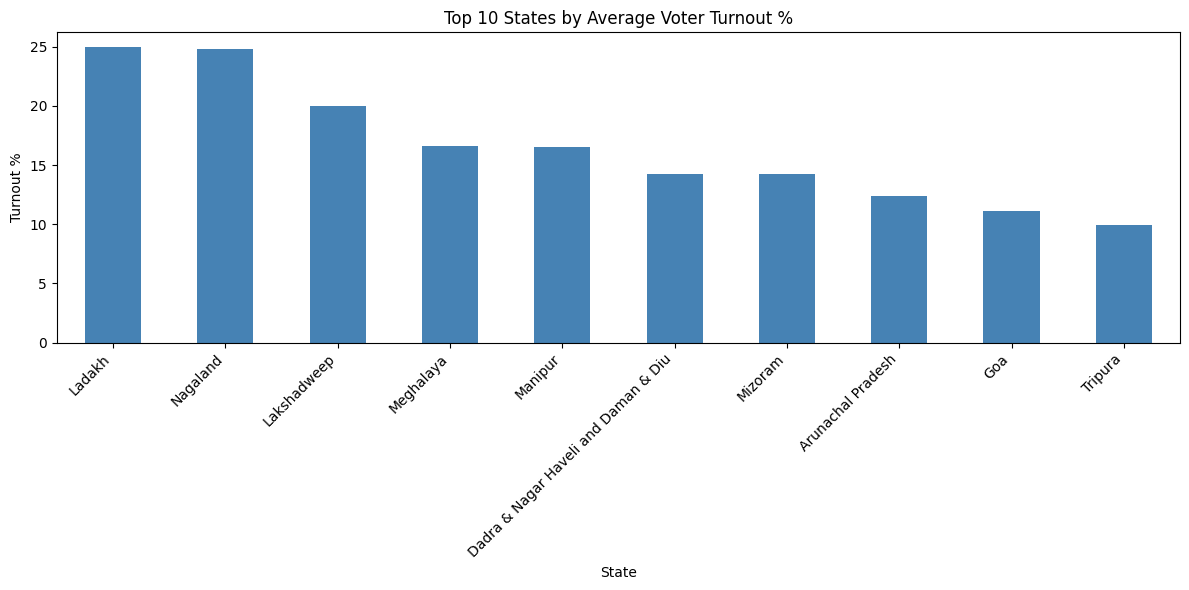

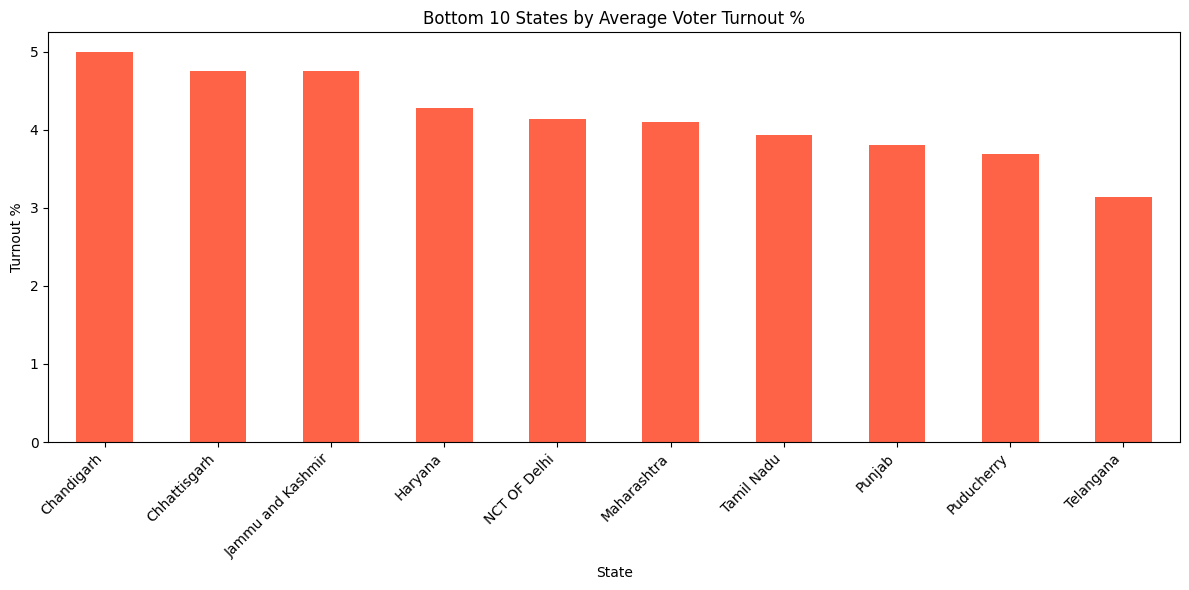

In [6]:
# Top 10 states by voter turnout
state_turnout = df.groupby('State')['Pct_Over_Votes_Polled'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
state_turnout.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 States by Average Voter Turnout %')
plt.xlabel('State')
plt.ylabel('Turnout %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Bottom 10 states
plt.figure(figsize=(12, 6))
state_turnout.tail(10).plot(kind='bar', color='tomato')
plt.title('Bottom 10 States by Average Voter Turnout %')
plt.xlabel('State')
plt.ylabel('Turnout %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# This counts how many candidates contested per constituency
# More candidates = more competition = more interesting fight

# groupby Constituency = group all rows by constituency name
# ['Candidate'].count() = count how many candidates in each group
candidates_per_constituency = df.groupby('Constituency')['Candidate'].count().sort_values(ascending=False)

print("Average candidates per constituency:", 
      round(candidates_per_constituency.mean(), 1))

# Show top 10 most contested constituencies
print("\nMost contested constituencies:")
print(candidates_per_constituency.head(10))

Average candidates per constituency: 16.5

Most contested constituencies:
Constituency
KARUR            55
Aurangabad       48
Secunderabad     46
Medak            45
Chevella         44
Ludhiana         44
Warangal         43
Peddapalle       43
Beed             42
CHENNAI SOUTH    42
Name: Candidate, dtype: int64


In [8]:
df_sorted = df.sort_values(['Constituency', 'Votes_Secured'], ascending=[True, False])

top2 = df_sorted.groupby('Constituency').head(2)
top2.head(6)

,State,Constituency,Candidate,Gender,Age,Category,Party,Symbol,Total_Votes_Polled,Valid_Votes,General_Votes,Postal_Votes,Votes_Secured,Pct_Over_Electors,Pct_Over_Votes_Polled,Pct_Over_Valid_Votes,Total_Electors,Is_Winner
4786,Rajasthan,AJMER,BHAGIRATH CHOUDHARY,MALE,69.0,GENERAL,BJP,Lotus,1202835.0,1189777.0,741151.0,6311.0,747462.0,37.38,62.14,62.82,1999399.0,1
4787,Rajasthan,AJMER,RAMCHANDRA CHOUDHARY,MALE,79.0,GENERAL,INC,Hand,1202835.0,1189777.0,413685.0,3786.0,417471.0,20.88,34.71,35.09,1999399.0,0
4746,Rajasthan,ALWAR,BHUPENDER YADAV,MALE,55.0,GENERAL,BJP,Lotus,1256821.0,1247616.0,624110.0,7882.0,631992.0,30.46,50.28,50.66,2075093.0,1
4747,Rajasthan,ALWAR,LALIT YADAV,MALE,37.0,GENERAL,INC,Hand,1256821.0,1247616.0,575964.0,7746.0,583710.0,28.13,46.44,46.79,2075093.0,0
1497,Haryana,AMBALA,VARUN CHAUDHRY,MALE,44.0,SC,INC,Hand,1348094.0,1340270.0,662592.0,1065.0,663657.0,33.12,49.23,49.52,2003510.0,1
1498,Haryana,AMBALA,BANTO KATARIA,FEMALE,59.0,SC,BJP,Lotus,1348094.0,1340270.0,613786.0,835.0,614621.0,30.68,45.59,45.86,2003510.0,0


In [9]:
# Group constituencies alphabetically, then rank candidates inside them by votes
df_s=df.sort_values(['Constituency', 'Votes_Secured'], ascending=[True, False])
top2=df_s.groupby('Constituency').head(2)

margin=top2.groupby('Constituency')['Votes_Secured'].diff().abs()
margin.head()
#top2.head()

4786         NaN
4787    329991.0
4746         NaN
4747     48282.0
1497         NaN
Name: Votes_Secured, dtype: float64

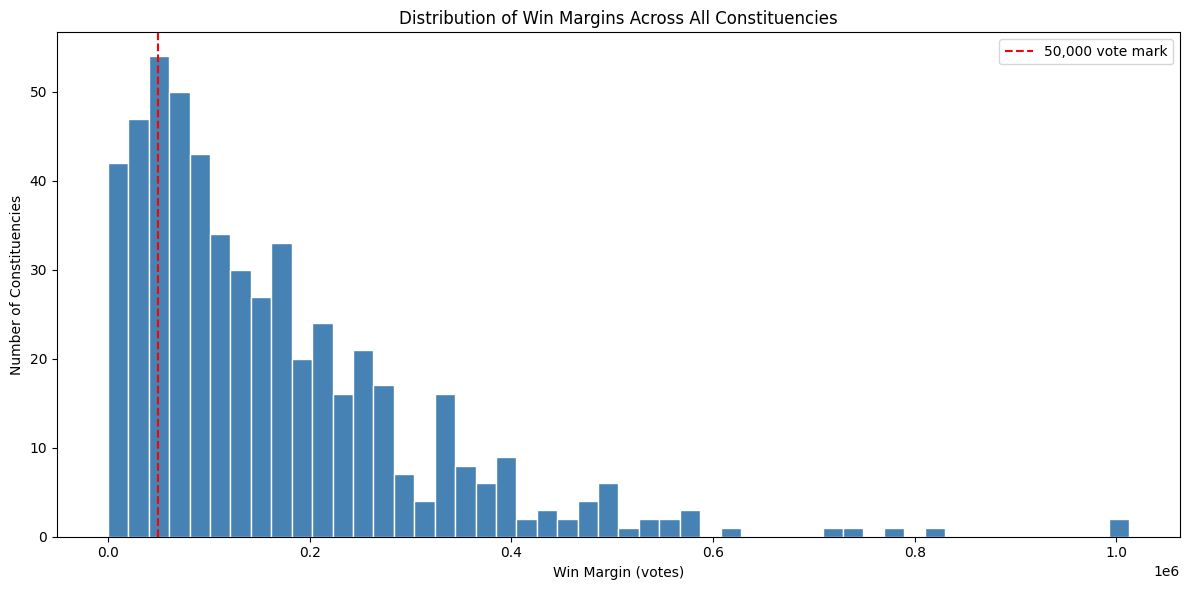

In [10]:
# plt.figure = set chart size
plt.figure(figsize=(12, 6))

# hist = histogram
# bins=50 = divide data into 50 groups
# color and edgecolor = styling
plt.hist(margin, bins=50, color='steelblue', edgecolor='white')

# labels and title
plt.title('Distribution of Win Margins Across All Constituencies')
plt.xlabel('Win Margin (votes)')  # x axis = margin size
plt.ylabel('Number of Constituencies')  # y axis = how many

# this draws a vertical red line at 50000 votes
# anything LEFT of this line = very close fight!
plt.axvline(x=50000, color='red', linestyle='--', label='50,000 vote mark')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Step 1: Count number of candidates per constituency
# This tells us how competitive each constituency was
candidates_count = df.groupby('Constituency')['Candidate'].count().reset_index()
candidates_count.columns = ['Constituency', 'Num_Candidates']

# Step 2: Get constituency level data
# We take only winner rows since they have constituency level info
constituency_df = df[df['Is_Winner'] == 1][['Constituency', 'State', 
                                             'Category', 'Total_Electors',
                                             'Total_Votes_Polled',
                                             'Pct_Over_Votes_Polled']].copy()

# Step 3: Merge candidate count into constituency data
constituency_df = constituency_df.merge(candidates_count, on='Constituency')

# Step 4: Check what we have
print("Shape:", constituency_df.shape)
print("\nFirst few rows:")
constituency_df.head()

print(constituency_df.describe())

Shape: (540, 7)

First few rows:
       Total_Electors  Total_Votes_Polled  Pct_Over_Votes_Polled  \
count    5.400000e+02        5.400000e+02             540.000000   
mean     1.803976e+06        1.193444e+06              50.256426   
std      3.609405e+05        2.450893e+05               7.681758   
min      5.795300e+04        4.924700e+04              23.650000   
25%      1.637910e+06        1.061658e+06              45.975000   
50%      1.823077e+06        1.179524e+06              49.700000   
75%      1.983377e+06        1.349964e+06              54.055000   
max      3.780453e+06        2.458780e+06              78.500000   

       Num_Candidates  
count      540.000000  
mean        16.483333  
std          8.380432  
min          4.000000  
25%         11.000000  
50%         14.000000  
75%         20.000000  
max         55.000000  


In [21]:
# Install required library
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries loaded!")

Libraries loaded!


In [34]:

df_model = pd.get_dummies(constituency_df, 
                           columns=['State', 'Category'])
X = df_model.drop(columns=['Constituency', 'Pct_Over_Votes_Polled', 
                             'Total_Votes_Polled'])
Y = df_model['Pct_Over_Votes_Polled']

# Step 3: Split again
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, 
                                                              test_size=0.15, 
                                                              random_state=42)

# Second split — separate validation from training (15% of total)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, 
                                                    test_size=0.176, 
                                                   random_state=42)
print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Testing size:", X_test.shape)
# # Step 4: Train again
model1 = LinearRegression()
model1.fit(X_train, Y_train)

# Step 5: Test again
Y_pred = model1.predict(X_test)
Y_pV=model1.predict(X_val)
Y_pt=model1.predict(X_train)

r2_2 = r2_score(Y_test, Y_pred)
r2_21 = r2_score(Y_val, Y_pV)
r2_22= r2_score(Y_train, Y_pt)
print(mae2)
print(r2_2,' ',r2_21,' ',r2_22)

Training size: (378, 41)
Validation size: (81, 41)
Testing size: (81, 41)
4.474818638832184
0.4297514598122082   0.41391873789662414   0.5045413167520955


In [14]:
# Load 2019 data
df_2019 = pd.read_csv('/kaggle/input/datasets/ishanabharathi/voter2019/33-Constituency-wise-detailed-result-2019.csv', 
                 header=2,
                 encoding='latin1')

print(df_2019.columns.tolist())

[' State Name ', ' PC NAME ', ' CANDIDATES NAME ', ' SEX ', ' AGE ', ' CATEGORY ', ' PARTY NAME ', ' PARTY SYMBOL ', ' GENERAL ', ' POSTAL ', ' TOTAL ', 'OVER TOTAL ELECTORS IN CONSTITUENCY', 'OVER TOTAL VOTES POLLED IN CONSTITUENCY', 'Total Electors']


In [15]:


# Rename to simpler names
df_2019.columns = ['State', 'Constituency', 'Candidate', 'Gender', 'Age', 
                    'Category', 'Party', 'Symbol', 'General_Votes', 
                    'Postal_Votes', 'Votes_Secured', 'Pct_Over_Electors',
                    'Pct_Over_Votes_Polled', 'Total_Electors']

# Fill missing State and Constituency (merged cells problem)
df_2019['State'] = df_2019['State'].ffill()
df_2019['Constituency'] = df_2019['Constituency'].ffill()

# Find 2019 winners
df_2019['Is_Winner'] = df_2019.groupby('Constituency')['Votes_Secured'].transform(
    lambda x: (x == x.max()).astype(int)
)

# Keep only winners
winners_2019 = df_2019[df_2019['Is_Winner'] == 1][['Constituency', 'Party']]
winners_2019.columns = ['Constituency', 'Party_2019']

print("2019 winners found:", len(winners_2019))
winners_2019.head()

2019 winners found: 540


,Constituency,Party_2019
2,Aruku,YSRCP
11,Srikakulam,TDP
23,Vizianagaram,YSRCP
39,Visakhapatnam,YSRCP
53,Anakapalli,YSRCP


In [42]:
winners_2024 = df[df['Is_Winner'] == 1][['Constituency', 'Party']]
winners_2024.columns = ['Constituency', 'Party_2024']
name_mapping = {
    'AHMADNAGAR': 'AHMEDNAGAR',
    'ANAKAPALLI': 'ANAKAPALLE',
    'ANANTAPUR': 'ANANTHAPUR',
    'ANANTNAG': 'ANANTNAG-RAJOURI',
    'ARAMBAGH': 'ARAMBAG',
    'AUTONOMOUS DISTRICT': 'DIPHU',
    'BAHRAICH': 'BAHARAICH',
    'BARDHAMAN DURGAPUR': 'BARDHAMAN-DURGAPUR',
    'BARRACKPORE': 'BARRACKPUR',
    'BHANDARA - GONDIYA': 'BHANDARA GONDIYA',
    'BIKANER (SC)': 'BIKANER',
    'COOCH BEHAR': 'COOCHBEHAR',
    'DADRA AND NAGAR HAVELI': 'DADAR & NAGAR HAVELI',
    'GADCHIROLI-CHIMUR': 'GADCHIROLI - CHIMUR',
    'GAUHATI': 'GUWAHATI',
    'GAYA (SC)': 'GAYA',
    'GOPALGANJ (SC)': 'GOPALGANJ',
    'HAJIPUR (SC)': 'HAJIPUR',
    'HARDWAR': 'HARIDWAR',
    'HATKANANGLE': 'HATKANANGALE',
    'JAMUI (SC)': 'JAMUI',
    'KALIABOR': 'KAZIRANGA',
    'KURNOOL': 'KURNOOLU',
    'MANGALDOI': 'DARRANG-UDALGURI',
    'MUMBAI   SOUTH': 'MUMBAI SOUTH',
    'NARASARAOPET': 'NARSARAOPET',
    'NORTH EAST DELHI': 'NORTH-EAST DELHI',
    'NORTH WEST DELHI': 'NORTH-WEST DELHI',
    'NOWGONG': 'NAGAON',
    'PALAMAU': 'PALAMU',
    'PATALIPUTRA': 'PATLIPUTRA',
    'RATNAGIRI - SINDHUDURG': 'RATNAGIRI- SINDHUDURG',
    'SAMASTIPUR (SC)': 'SAMASTIPUR',
    'SARGUJA': 'SURGUJA',
    'SASARAM (SC)': 'SASARAM',
    'SECUNDRABAD': 'SECUNDERABAD',
    'SRERAMPUR': 'SREERAMPUR',
    'TEZPUR': 'SONITPUR',
    'THIRUVALLUR': 'TIRUVALLUR',
    'TIRUPATI': 'THIRUPATHI',
    'YAVATMAL-WASHIM': 'YAVATMAL- WASHIM',
}

# Apply mapping
winners_2019['Constituency'] = winners_2019['Constituency'].replace(name_mapping)
# Convert all constituency names to UPPERCASE in both datasets
winners_2019['Constituency'] = winners_2019['Constituency'].str.upper().str.strip()
winners_2024['Constituency'] = winners_2024['Constituency'].str.upper().str.strip()

# Merge again
incumbency_df = winners_2019.merge(winners_2024, on='Constituency')

# Compare again
incumbency_df['Anti_Incumbency'] = (
    incumbency_df['Party_2019'] != incumbency_df['Party_2024']
).astype(int)

total = len(incumbency_df)
anti = incumbency_df['Anti_Incumbency'].sum()
retained = total - anti

print(f"Total constituencies: {total}")
print(f"Anti-incumbency (party changed): {anti} ({round(anti/total*100,1)}%)")
print(f"Retained (same party won): {retained} ({round(retained/total*100,1)}%)")

Total constituencies: 539
Anti-incumbency (party changed): 214 (39.7%)
Retained (same party won): 325 (60.3%)


In [44]:
# Rebuild margins completely from scratch
df_sorted2 = df.copy()
df_sorted2['Constituency'] = df_sorted2['Constituency'].str.upper().str.strip()

# Sort by constituency and votes
df_sorted2 = df_sorted2.sort_values(['Constituency', 'Votes_Secured'], 
                                     ascending=[True, False])

# Get top 2 per constituency
top2 = df_sorted2.groupby('Constituency').head(2)

# Calculate margin
margins_df = top2.groupby('Constituency')['Votes_Secured'].apply(
    lambda x: x.iloc[0] - x.iloc[1] if len(x) == 2 else None
).reset_index()

margins_df.columns = ['Constituency', 'Win_Margin']

print("Sample:")
print(margins_df.head(10))

Sample:
     Constituency  Win_Margin
0        ADILABAD     90652.0
1            AGRA    271294.0
2  AHMEDABAD EAST    461755.0
3  AHMEDABAD WEST    286437.0
4      AHMEDNAGAR     28929.0
5           AJMER    329991.0
6        AKBARPUR     44345.0
7           AKOLA     40626.0
8       ALAPPUZHA     63513.0
9         ALATHUR     20111.0


In [45]:
# Make sure constituency_df is also uppercase
constituency_df['Constituency'] = constituency_df['Constituency'].str.upper().str.strip()

# Merge all 3 together
model2_df = incumbency_df.merge(constituency_df, on='Constituency')
model2_df = model2_df.merge(margins_df, on='Constituency')

print("Shape:", model2_df.shape)
print("\nAnti-incumbency distribution:")
print(model2_df['Anti_Incumbency'].value_counts())

Shape: (541, 11)

Anti-incumbency distribution:
Anti_Incumbency
0    326
1    215
Name: count, dtype: int64


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Prepare inputs
# Convert State and Category to numbers
model2_encoded = pd.get_dummies(model2_df, columns=['State', 'Category'])

# Step 2: X = inputs, Y = output
X = model2_encoded.drop(columns=['Constituency', 'Party_2019', 
                                   'Party_2024', 'Anti_Incumbency',
                                   'Total_Votes_Polled'])
Y = model2_encoded['Anti_Incumbency']

# Step 3: Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                      test_size=0.2, 
                                                      random_state=42)

# Step 4: Train
model_anti = LogisticRegression(max_iter=1000)
model_anti.fit(X_train, Y_train)

# Step 5: Test
Y_pred = model_anti.predict(X_test)
print("Accuracy:", round(accuracy_score(Y_test, Y_pred)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(Y_test, Y_pred))

Accuracy: 67.89 %

Detailed Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        66
           1       0.62      0.47      0.53        43

    accuracy                           0.68       109
   macro avg       0.66      0.64      0.64       109
weighted avg       0.67      0.68      0.67       109



In [ ]:
def classify_swing(margin):
    if margin < 50000:
        return 'High Swing'
    elif margin < 150000:
        return 'Medium Swing'
    else:
        return 'Safe'

margins_df['Swing_Type'] = margins_df['Win_Margin'].apply(classify_swing)

print("Swing distribution:")
print(margins_df['Swing_Type'].value_counts())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Merge swing data with constituency data
model3_df = margins_df.merge(constituency_df, on='Constituency')

# Encode swing type as numbers
le = LabelEncoder()
model3_df['Swing_Label'] = le.fit_transform(model3_df['Swing_Type'])

# Encode State and Category
model3_encoded = pd.get_dummies(model3_df, columns=['State', 'Category'])

# X and Y
X = model3_encoded.drop(columns=['Constituency', 'Swing_Type', 
                                   'Swing_Label', 'Win_Margin',
                                   'Total_Votes_Polled'])
Y = model3_encoded['Swing_Label']

# Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                      test_size=0.2, 
                                                      random_state=42)

# Train Random Forest
model_swing = RandomForestClassifier(n_estimators=100, random_state=42)
model_swing.fit(X_train, Y_train)

# Test
Y_pred = model_swing.predict(X_test)
print("Accuracy:", round(accuracy_score(Y_test, Y_pred)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(Y_test, Y_pred, target_names=le.classes_))

In [ ]:
# Which factors matter most for predicting swing?
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_swing.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 most important factors:")
print(feature_importance.head(10))

# Plot it
plt.figure(figsize=(12, 6))
feature_importance.head(10).plot(kind='bar', x='Feature', y='Importance', 
                                  color='steelblue', legend=False)
plt.title('Top 10 Factors That Decide If A Constituency Is Swing')
plt.xlabel('Factor')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# How many rows and columns?
df = pd.read_csv('/kaggle/input/datasets/ishanabharathi/voters/33-Constituency-Wise-Detailed-Result.csv', 
                 header=2,
                 encoding='latin1')



print("Shape:", df.shape)

# What are the column names?
print("\nColumns:")
print(df.columns.tolist())


In [3]:
# Drop useless columns
df = df.drop(columns=['Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19'])

# Rename columns to simpler names
df.columns = ['State', 'Constituency', 'Candidate', 'Gender', 'Age', 
              'Category', 'Party', 'Symbol', 'Total_Votes_Polled', 
              'Valid_Votes', 'General_Votes', 'Postal_Votes', 
              'Votes_Secured', 'Pct_Over_Electors', 
              'Pct_Over_Votes_Polled', 'Pct_Over_Valid_Votes', 
              'Total_Electors']
df.head()

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Quick look
df.head()

Missing values:
State                      5
Constituency               8
Candidate                  8
Gender                   550
Age                      550
Category                 550
Party                      8
Symbol                     8
Total_Votes_Polled         8
Valid_Votes                8
General_Votes              8
Postal_Votes               8
Votes_Secured              8
Pct_Over_Electors          8
Pct_Over_Votes_Polled      8
Pct_Over_Valid_Votes       8
Total_Electors             8
dtype: int64


,State,Constituency,Candidate,Gender,Age,Category,Party,Symbol,Total_Votes_Polled,Valid_Votes,General_Votes,Postal_Votes,Votes_Secured,Pct_Over_Electors,Pct_Over_Votes_Polled,Pct_Over_Valid_Votes,Total_Electors
0,Andhra Pradesh,Araku,GUMMA THANUJA RANI,FEMALE,31.0,ST,YSRCP,Ceiling fan,1165787.0,1113975.0,471470.0,5535.0,477005.0,30.63,40.92,42.82,1557153.0
1,Andhra Pradesh,Araku,KOTHAPALLI GEETHA,FEMALE,53.0,ST,BJP,Lotus,1165787.0,1113975.0,417113.0,9312.0,426425.0,27.38,36.58,38.28,1557153.0
2,Andhra Pradesh,Araku,APPALANARASA PACHIPENTA,MALE,41.0,ST,CPI(M),"Hammer, Sickle and Star",1165787.0,1113975.0,119016.0,4113.0,123129.0,7.91,10.56,11.05,1557153.0
3,Andhra Pradesh,Araku,NOTA,NaN,NaN,NaN,NOTA,NOTA,1165787.0,1113975.0,50205.0,265.0,50470.0,3.24,4.33,4.53,1557153.0
4,Andhra Pradesh,Araku,AVASHYA LAHARI . VARAM,FEMALE,30.0,ST,BSP,Elephant,1165787.0,1113975.0,24858.0,892.0,25750.0,1.65,2.21,2.31,1557153.0


In [4]:
# Fill missing State and Constituency 
# (they're missing because Excel merged cells)
df['State'] = df['State'].ffill()
df['Constituency'] = df['Constituency'].ffill()

# Fill missing Gender, Age, Category with 'Unknown'
df['Gender'] = df['Gender'].fillna('Unknown')
df['Age'] = df['Age'].fillna(0)
df['Category'] = df['Category'].fillna('Unknown')

# Drop remaining missing rows (only 8 rows - very small)
df = df.dropna()

# Confirm - should show all zeros now
print("Missing values after fix:")
print(df.isnull().sum())

print("\nShape now:", df.shape)

Missing values after fix:
State                    0
Constituency             0
Candidate                0
Gender                   0
Age                      0
Category                 0
Party                    0
Symbol                   0
Total_Votes_Polled       0
Valid_Votes              0
General_Votes            0
Postal_Votes             0
Votes_Secured            0
Pct_Over_Electors        0
Pct_Over_Votes_Polled    0
Pct_Over_Valid_Votes     0
Total_Electors           0
dtype: int64

Shape now: (8901, 17)


In [5]:
# Find the winner of each constituency
# (candidate with highest votes in each constituency)

df['Is_Winner'] = df.groupby('Constituency')['Votes_Secured'].transform(
    lambda x: (x == x.max()).astype(int)
)

# Check - should show 0s and 1s
print("Winners found:", df['Is_Winner'].sum())
print("Total constituencies:", df['Constituency'].nunique())

# See what a winner row looks like
df[df['Is_Winner'] == 1].head()

Winners found: 540
Total constituencies: 540


,State,Constituency,Candidate,Gender,Age,Category,Party,Symbol,Total_Votes_Polled,Valid_Votes,General_Votes,Postal_Votes,Votes_Secured,Pct_Over_Electors,Pct_Over_Votes_Polled,Pct_Over_Valid_Votes,Total_Electors,Is_Winner
0,Andhra Pradesh,Araku,GUMMA THANUJA RANI,FEMALE,31.0,ST,YSRCP,Ceiling fan,1165787.0,1113975.0,471470.0,5535.0,477005.0,30.63,40.92,42.82,1557153.0,1
14,Andhra Pradesh,Srikakulam,KINJARAPU RAMMOHAN NAIDU,MALE,36.0,GENERAL,TDP,Bicycle,1241169.0,1211081.0,734501.0,19827.0,754328.0,45.81,60.78,62.29,1646686.0,1
28,Andhra Pradesh,Vizianagaram,APPALANAIDU KALISETTI,MALE,50.0,GENERAL,TDP,Bicycle,1307632.0,1275992.0,729284.0,13829.0,743113.0,46.71,56.83,58.24,1590994.0,1
44,Andhra Pradesh,Visakhapatnam,SRIBHARAT MATHUKUMILI,MALE,35.0,GENERAL,TDP,Bicycle,1391130.0,1381812.0,893884.0,13583.0,907467.0,46.98,65.23,65.67,1931398.0,1
78,Andhra Pradesh,Anakapalle,C.M.RAMESH,MALE,58.0,GENERAL,BJP,Lotus,1328726.0,1299097.0,750027.0,12042.0,762069.0,47.59,57.35,58.66,1601365.0,1


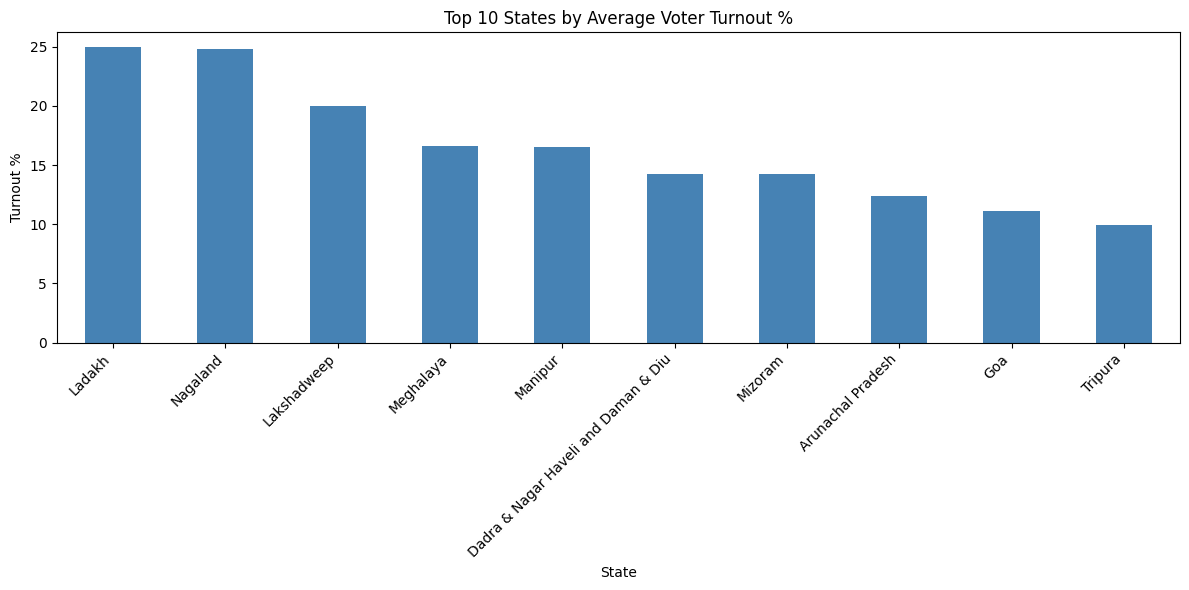

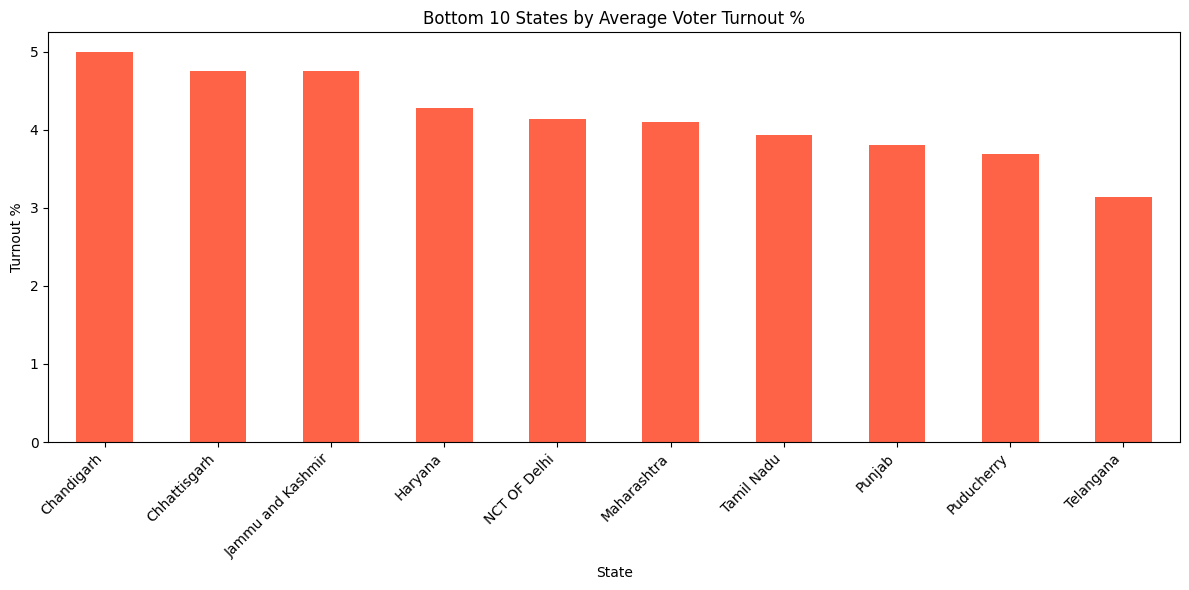

In [6]:
# Top 10 states by voter turnout
state_turnout = df.groupby('State')['Pct_Over_Votes_Polled'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
state_turnout.head(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 States by Average Voter Turnout %')
plt.xlabel('State')
plt.ylabel('Turnout %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Bottom 10 states
plt.figure(figsize=(12, 6))
state_turnout.tail(10).plot(kind='bar', color='tomato')
plt.title('Bottom 10 States by Average Voter Turnout %')
plt.xlabel('State')
plt.ylabel('Turnout %')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [7]:
# This counts how many candidates contested per constituency
# More candidates = more competition = more interesting fight

# groupby Constituency = group all rows by constituency name
# ['Candidate'].count() = count how many candidates in each group
candidates_per_constituency = df.groupby('Constituency')['Candidate'].count().sort_values(ascending=False)

print("Average candidates per constituency:", 
      round(candidates_per_constituency.mean(), 1))

# Show top 10 most contested constituencies
print("\nMost contested constituencies:")
print(candidates_per_constituency.head(10))

Average candidates per constituency: 16.5

Most contested constituencies:
Constituency
KARUR            55
Aurangabad       48
Secunderabad     46
Medak            45
Chevella         44
Ludhiana         44
Warangal         43
Peddapalle       43
Beed             42
CHENNAI SOUTH    42
Name: Candidate, dtype: int64


In [8]:
df_sorted = df.sort_values(['Constituency', 'Votes_Secured'], ascending=[True, False])

top2 = df_sorted.groupby('Constituency').head(2)
top2.head(6)

,State,Constituency,Candidate,Gender,Age,Category,Party,Symbol,Total_Votes_Polled,Valid_Votes,General_Votes,Postal_Votes,Votes_Secured,Pct_Over_Electors,Pct_Over_Votes_Polled,Pct_Over_Valid_Votes,Total_Electors,Is_Winner
4786,Rajasthan,AJMER,BHAGIRATH CHOUDHARY,MALE,69.0,GENERAL,BJP,Lotus,1202835.0,1189777.0,741151.0,6311.0,747462.0,37.38,62.14,62.82,1999399.0,1
4787,Rajasthan,AJMER,RAMCHANDRA CHOUDHARY,MALE,79.0,GENERAL,INC,Hand,1202835.0,1189777.0,413685.0,3786.0,417471.0,20.88,34.71,35.09,1999399.0,0
4746,Rajasthan,ALWAR,BHUPENDER YADAV,MALE,55.0,GENERAL,BJP,Lotus,1256821.0,1247616.0,624110.0,7882.0,631992.0,30.46,50.28,50.66,2075093.0,1
4747,Rajasthan,ALWAR,LALIT YADAV,MALE,37.0,GENERAL,INC,Hand,1256821.0,1247616.0,575964.0,7746.0,583710.0,28.13,46.44,46.79,2075093.0,0
1497,Haryana,AMBALA,VARUN CHAUDHRY,MALE,44.0,SC,INC,Hand,1348094.0,1340270.0,662592.0,1065.0,663657.0,33.12,49.23,49.52,2003510.0,1
1498,Haryana,AMBALA,BANTO KATARIA,FEMALE,59.0,SC,BJP,Lotus,1348094.0,1340270.0,613786.0,835.0,614621.0,30.68,45.59,45.86,2003510.0,0


In [9]:
# Group constituencies alphabetically, then rank candidates inside them by votes
df_s=df.sort_values(['Constituency', 'Votes_Secured'], ascending=[True, False])
top2=df_s.groupby('Constituency').head(2)

margin=top2.groupby('Constituency')['Votes_Secured'].diff().abs()
margin.head()
#top2.head()

4786         NaN
4787    329991.0
4746         NaN
4747     48282.0
1497         NaN
Name: Votes_Secured, dtype: float64

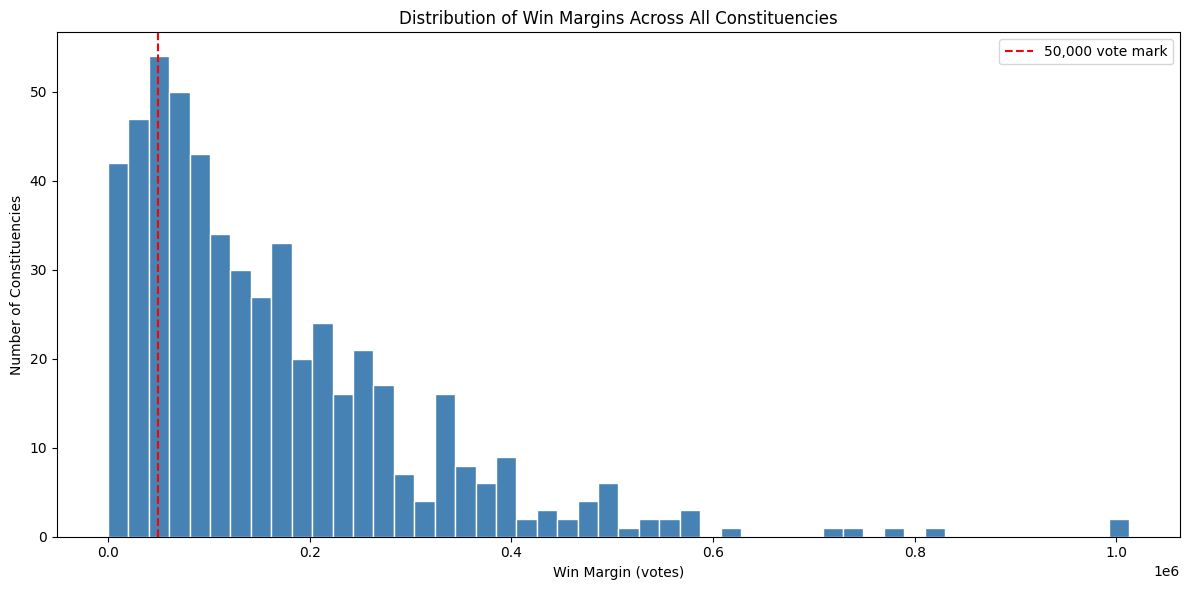

In [10]:
# plt.figure = set chart size
plt.figure(figsize=(12, 6))

# hist = histogram
# bins=50 = divide data into 50 groups
# color and edgecolor = styling
plt.hist(margin, bins=50, color='steelblue', edgecolor='white')

# labels and title
plt.title('Distribution of Win Margins Across All Constituencies')
plt.xlabel('Win Margin (votes)')  # x axis = margin size
plt.ylabel('Number of Constituencies')  # y axis = how many

# this draws a vertical red line at 50000 votes
# anything LEFT of this line = very close fight!
plt.axvline(x=50000, color='red', linestyle='--', label='50,000 vote mark')
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Step 1: Count number of candidates per constituency
# This tells us how competitive each constituency was
candidates_count = df.groupby('Constituency')['Candidate'].count().reset_index()
candidates_count.columns = ['Constituency', 'Num_Candidates']

# Step 2: Get constituency level data
# We take only winner rows since they have constituency level info
constituency_df = df[df['Is_Winner'] == 1][['Constituency', 'State', 
                                             'Category', 'Total_Electors',
                                             'Total_Votes_Polled',
                                             'Pct_Over_Votes_Polled']].copy()

# Step 3: Merge candidate count into constituency data
constituency_df = constituency_df.merge(candidates_count, on='Constituency')

# Step 4: Check what we have
print("Shape:", constituency_df.shape)
print("\nFirst few rows:")
constituency_df.head()

print(constituency_df.describe())

Shape: (540, 7)

First few rows:
       Total_Electors  Total_Votes_Polled  Pct_Over_Votes_Polled  \
count    5.400000e+02        5.400000e+02             540.000000   
mean     1.803976e+06        1.193444e+06              50.256426   
std      3.609405e+05        2.450893e+05               7.681758   
min      5.795300e+04        4.924700e+04              23.650000   
25%      1.637910e+06        1.061658e+06              45.975000   
50%      1.823077e+06        1.179524e+06              49.700000   
75%      1.983377e+06        1.349964e+06              54.055000   
max      3.780453e+06        2.458780e+06              78.500000   

       Num_Candidates  
count      540.000000  
mean        16.483333  
std          8.380432  
min          4.000000  
25%         11.000000  
50%         14.000000  
75%         20.000000  
max         55.000000  


In [21]:
# Install required library
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

print("Libraries loaded!")

Libraries loaded!


In [34]:

df_model = pd.get_dummies(constituency_df, 
                           columns=['State', 'Category'])
X = df_model.drop(columns=['Constituency', 'Pct_Over_Votes_Polled', 
                             'Total_Votes_Polled'])
Y = df_model['Pct_Over_Votes_Polled']

# Step 3: Split again
X_train_val, X_test, Y_train_val, Y_test = train_test_split(X, Y, 
                                                              test_size=0.15, 
                                                              random_state=42)

# Second split — separate validation from training (15% of total)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_val, Y_train_val, 
                                                    test_size=0.176, 
                                                   random_state=42)
print("Training size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Testing size:", X_test.shape)
# # Step 4: Train again
model1 = LinearRegression()
model1.fit(X_train, Y_train)

# Step 5: Test again
Y_pred = model1.predict(X_test)
Y_pV=model1.predict(X_val)
Y_pt=model1.predict(X_train)

r2_2 = r2_score(Y_test, Y_pred)
r2_21 = r2_score(Y_val, Y_pV)
r2_22= r2_score(Y_train, Y_pt)
print(mae2)
print(r2_2,' ',r2_21,' ',r2_22)

Training size: (378, 41)
Validation size: (81, 41)
Testing size: (81, 41)
4.474818638832184
0.4297514598122082   0.41391873789662414   0.5045413167520955


In [14]:
# Load 2019 data
df_2019 = pd.read_csv('/kaggle/input/datasets/ishanabharathi/voter2019/33-Constituency-wise-detailed-result-2019.csv', 
                 header=2,
                 encoding='latin1')

print(df_2019.columns.tolist())

[' State Name ', ' PC NAME ', ' CANDIDATES NAME ', ' SEX ', ' AGE ', ' CATEGORY ', ' PARTY NAME ', ' PARTY SYMBOL ', ' GENERAL ', ' POSTAL ', ' TOTAL ', 'OVER TOTAL ELECTORS IN CONSTITUENCY', 'OVER TOTAL VOTES POLLED IN CONSTITUENCY', 'Total Electors']


In [15]:


# Rename to simpler names
df_2019.columns = ['State', 'Constituency', 'Candidate', 'Gender', 'Age', 
                    'Category', 'Party', 'Symbol', 'General_Votes', 
                    'Postal_Votes', 'Votes_Secured', 'Pct_Over_Electors',
                    'Pct_Over_Votes_Polled', 'Total_Electors']

# Fill missing State and Constituency (merged cells problem)
df_2019['State'] = df_2019['State'].ffill()
df_2019['Constituency'] = df_2019['Constituency'].ffill()

# Find 2019 winners
df_2019['Is_Winner'] = df_2019.groupby('Constituency')['Votes_Secured'].transform(
    lambda x: (x == x.max()).astype(int)
)

# Keep only winners
winners_2019 = df_2019[df_2019['Is_Winner'] == 1][['Constituency', 'Party']]
winners_2019.columns = ['Constituency', 'Party_2019']

print("2019 winners found:", len(winners_2019))
winners_2019.head()

2019 winners found: 540


,Constituency,Party_2019
2,Aruku,YSRCP
11,Srikakulam,TDP
23,Vizianagaram,YSRCP
39,Visakhapatnam,YSRCP
53,Anakapalli,YSRCP


In [42]:
winners_2024 = df[df['Is_Winner'] == 1][['Constituency', 'Party']]
winners_2024.columns = ['Constituency', 'Party_2024']
name_mapping = {
    'AHMADNAGAR': 'AHMEDNAGAR',
    'ANAKAPALLI': 'ANAKAPALLE',
    'ANANTAPUR': 'ANANTHAPUR',
    'ANANTNAG': 'ANANTNAG-RAJOURI',
    'ARAMBAGH': 'ARAMBAG',
    'AUTONOMOUS DISTRICT': 'DIPHU',
    'BAHRAICH': 'BAHARAICH',
    'BARDHAMAN DURGAPUR': 'BARDHAMAN-DURGAPUR',
    'BARRACKPORE': 'BARRACKPUR',
    'BHANDARA - GONDIYA': 'BHANDARA GONDIYA',
    'BIKANER (SC)': 'BIKANER',
    'COOCH BEHAR': 'COOCHBEHAR',
    'DADRA AND NAGAR HAVELI': 'DADAR & NAGAR HAVELI',
    'GADCHIROLI-CHIMUR': 'GADCHIROLI - CHIMUR',
    'GAUHATI': 'GUWAHATI',
    'GAYA (SC)': 'GAYA',
    'GOPALGANJ (SC)': 'GOPALGANJ',
    'HAJIPUR (SC)': 'HAJIPUR',
    'HARDWAR': 'HARIDWAR',
    'HATKANANGLE': 'HATKANANGALE',
    'JAMUI (SC)': 'JAMUI',
    'KALIABOR': 'KAZIRANGA',
    'KURNOOL': 'KURNOOLU',
    'MANGALDOI': 'DARRANG-UDALGURI',
    'MUMBAI   SOUTH': 'MUMBAI SOUTH',
    'NARASARAOPET': 'NARSARAOPET',
    'NORTH EAST DELHI': 'NORTH-EAST DELHI',
    'NORTH WEST DELHI': 'NORTH-WEST DELHI',
    'NOWGONG': 'NAGAON',
    'PALAMAU': 'PALAMU',
    'PATALIPUTRA': 'PATLIPUTRA',
    'RATNAGIRI - SINDHUDURG': 'RATNAGIRI- SINDHUDURG',
    'SAMASTIPUR (SC)': 'SAMASTIPUR',
    'SARGUJA': 'SURGUJA',
    'SASARAM (SC)': 'SASARAM',
    'SECUNDRABAD': 'SECUNDERABAD',
    'SRERAMPUR': 'SREERAMPUR',
    'TEZPUR': 'SONITPUR',
    'THIRUVALLUR': 'TIRUVALLUR',
    'TIRUPATI': 'THIRUPATHI',
    'YAVATMAL-WASHIM': 'YAVATMAL- WASHIM',
}

# Apply mapping
winners_2019['Constituency'] = winners_2019['Constituency'].replace(name_mapping)
# Convert all constituency names to UPPERCASE in both datasets
winners_2019['Constituency'] = winners_2019['Constituency'].str.upper().str.strip()
winners_2024['Constituency'] = winners_2024['Constituency'].str.upper().str.strip()

# Merge again
incumbency_df = winners_2019.merge(winners_2024, on='Constituency')

# Compare again
incumbency_df['Anti_Incumbency'] = (
    incumbency_df['Party_2019'] != incumbency_df['Party_2024']
).astype(int)

total = len(incumbency_df)
anti = incumbency_df['Anti_Incumbency'].sum()
retained = total - anti

print(f"Total constituencies: {total}")
print(f"Anti-incumbency (party changed): {anti} ({round(anti/total*100,1)}%)")
print(f"Retained (same party won): {retained} ({round(retained/total*100,1)}%)")

Total constituencies: 539
Anti-incumbency (party changed): 214 (39.7%)
Retained (same party won): 325 (60.3%)


In [44]:
# Rebuild margins completely from scratch
df_sorted2 = df.copy()
df_sorted2['Constituency'] = df_sorted2['Constituency'].str.upper().str.strip()

# Sort by constituency and votes
df_sorted2 = df_sorted2.sort_values(['Constituency', 'Votes_Secured'], 
                                     ascending=[True, False])

# Get top 2 per constituency
top2 = df_sorted2.groupby('Constituency').head(2)

# Calculate margin
margins_df = top2.groupby('Constituency')['Votes_Secured'].apply(
    lambda x: x.iloc[0] - x.iloc[1] if len(x) == 2 else None
).reset_index()

margins_df.columns = ['Constituency', 'Win_Margin']

print("Sample:")
print(margins_df.head(10))

Sample:
     Constituency  Win_Margin
0        ADILABAD     90652.0
1            AGRA    271294.0
2  AHMEDABAD EAST    461755.0
3  AHMEDABAD WEST    286437.0
4      AHMEDNAGAR     28929.0
5           AJMER    329991.0
6        AKBARPUR     44345.0
7           AKOLA     40626.0
8       ALAPPUZHA     63513.0
9         ALATHUR     20111.0


In [45]:
# Make sure constituency_df is also uppercase
constituency_df['Constituency'] = constituency_df['Constituency'].str.upper().str.strip()

# Merge all 3 together
model2_df = incumbency_df.merge(constituency_df, on='Constituency')
model2_df = model2_df.merge(margins_df, on='Constituency')

print("Shape:", model2_df.shape)
print("\nAnti-incumbency distribution:")
print(model2_df['Anti_Incumbency'].value_counts())

Shape: (541, 11)

Anti-incumbency distribution:
Anti_Incumbency
0    326
1    215
Name: count, dtype: int64


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Step 1: Prepare inputs
# Convert State and Category to numbers
model2_encoded = pd.get_dummies(model2_df, columns=['State', 'Category'])

# Step 2: X = inputs, Y = output
X = model2_encoded.drop(columns=['Constituency', 'Party_2019', 
                                   'Party_2024', 'Anti_Incumbency',
                                   'Total_Votes_Polled'])
Y = model2_encoded['Anti_Incumbency']

# Step 3: Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                      test_size=0.2, 
                                                      random_state=42)

# Step 4: Train
model_anti = LogisticRegression(max_iter=1000)
model_anti.fit(X_train, Y_train)

# Step 5: Test
Y_pred = model_anti.predict(X_test)
print("Accuracy:", round(accuracy_score(Y_test, Y_pred)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(Y_test, Y_pred))

Accuracy: 67.89 %

Detailed Report:
              precision    recall  f1-score   support

           0       0.70      0.82      0.76        66
           1       0.62      0.47      0.53        43

    accuracy                           0.68       109
   macro avg       0.66      0.64      0.64       109
weighted avg       0.67      0.68      0.67       109



In [ ]:
def classify_swing(margin):
    if margin < 50000:
        return 'High Swing'
    elif margin < 150000:
        return 'Medium Swing'
    else:
        return 'Safe'

margins_df['Swing_Type'] = margins_df['Win_Margin'].apply(classify_swing)

print("Swing distribution:")
print(margins_df['Swing_Type'].value_counts())

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

# Merge swing data with constituency data
model3_df = margins_df.merge(constituency_df, on='Constituency')

# Encode swing type as numbers
le = LabelEncoder()
model3_df['Swing_Label'] = le.fit_transform(model3_df['Swing_Type'])

# Encode State and Category
model3_encoded = pd.get_dummies(model3_df, columns=['State', 'Category'])

# X and Y
X = model3_encoded.drop(columns=['Constituency', 'Swing_Type', 
                                   'Swing_Label', 'Win_Margin',
                                   'Total_Votes_Polled'])
Y = model3_encoded['Swing_Label']

# Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, 
                                                      test_size=0.2, 
                                                      random_state=42)

# Train Random Forest
model_swing = RandomForestClassifier(n_estimators=100, random_state=42)
model_swing.fit(X_train, Y_train)

# Test
Y_pred = model_swing.predict(X_test)
print("Accuracy:", round(accuracy_score(Y_test, Y_pred)*100, 2), "%")
print("\nDetailed Report:")
print(classification_report(Y_test, Y_pred, target_names=le.classes_))

In [ ]:
# Which factors matter most for predicting swing?
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_swing.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 10 most important factors:")
print(feature_importance.head(10))

# Plot it
plt.figure(figsize=(12, 6))
feature_importance.head(10).plot(kind='bar', x='Feature', y='Importance', 
                                  color='steelblue', legend=False)
plt.title('Top 10 Factors That Decide If A Constituency Is Swing')
plt.xlabel('Factor')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()